In [25]:
# Activity 3.1 – Compile the Model

In [26]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [27]:
train_dir = r"C:\projects\Smart_bridge\archive\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train"

valid_dir = r"C:\projects\Smart_bridge\archive\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid"

In [28]:
import os

print(os.listdir(r"C:\projects\Smart_bridge\archive\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)"))

['train']


In [29]:
train_gen = datagen.flow_from_directory(
    r"C:\projects\Smart_bridge\archive\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 10479 images belonging to 8 classes.


In [30]:
valid_gen = datagen.flow_from_directory(
    r"C:\projects\Smart_bridge\archive\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2617 images belonging to 8 classes.


In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224,224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,   # 20% validation
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.15
)

In [32]:
#model building

In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),   # VERY IMPORTANT
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
#Activity 3.2 - setup callbacks

In [36]:
from tensorflow import keras

callbacks = [

    keras.callbacks.ModelCheckpoint(
        "mobilenetv2_best.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

print("Callbacks configured successfully!")

Callbacks configured successfully!


In [37]:
#Activity 3.3 - Model Training

In [ ]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5
)

Epoch 1/5
 44/328 ━━━━━━━━━━━━━━━━━━━━ 4:02 856ms/step - accuracy: 0.3323 - loss: 1.8355

In [ ]:
model.save("plant_disease_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
#Activity 3.4 - Visualisation

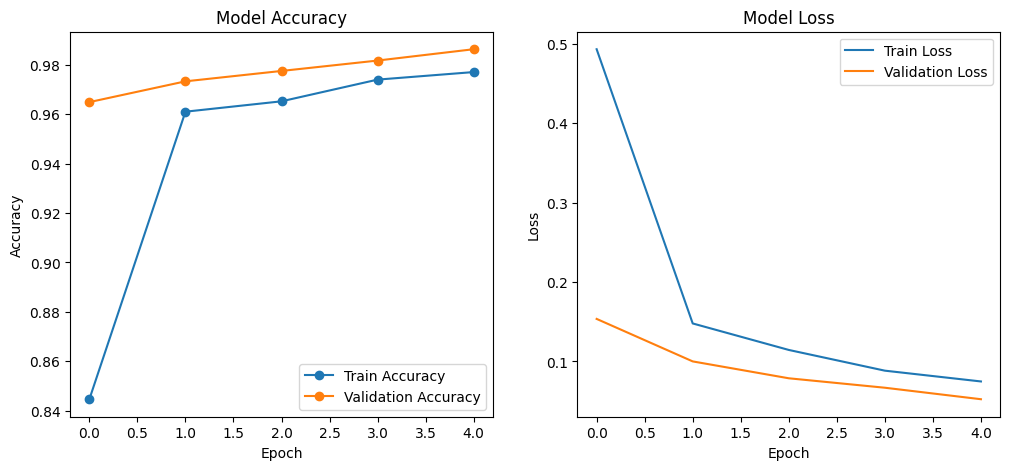

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()